In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

from matplotlib import pyplot as plt

In [25]:
transform = transforms.Compose([
    transforms.ToTensor(), # 0 --> 255 ==> (0,1)
    transforms.Normalize((0.5),(0.5)),# (0,1) ==> [-1,1]
])
training_dataset = datasets.MNIST(
    root = "data",
    download = True,
    train = True,
    transform = transform
)
test_dataset = datasets.MNIST(
    root = "data",
    download = True,
    train = False,
    transform = transform
)

In [26]:
len(training_dataset)

60000

In [27]:
len(test_dataset)

10000

In [28]:
train_loader = DataLoader(training_dataset,batch_size = 64,shuffle = True)
test_loader = DataLoader(test_dataset,batch_size = 64,shuffle = True)

In [29]:
data_iter = iter(train_loader)
imgs, labels = next(data_iter)

In [30]:
imgs[0].squeeze().shape

torch.Size([28, 28])

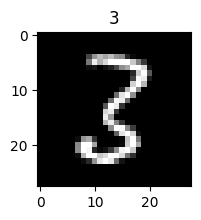

In [31]:
plt.figure(figsize = (2,2))
plt.title(labels[0].item())
plt.imshow(imgs[0].squeeze(),cmap ="gray")
plt.show()


In [34]:
class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network =  nn.Sequential(
            nn.Flatten(),
            nn.Linear(784,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
    def forward(self,x):
        return self.network(x)
        

In [35]:
model = DigitClassifier()
optimizer = optim.Adam(model.parameters(),lr =  0.001)
criterion = nn.CrossEntropyLoss()

In [40]:
epochs = 5
for epoch in range(epochs):
    running_loss = 0.0
    for images,labels in train_loader:
        
        # Forward Pass 
        outputs = model(images)
        loss =  criterion(outputs,labels)

        running_loss += loss.item()
        # Backward Pass
        optimizer.zero_grad()
        loss.backward()
        
        # weights updates
        optimizer.step() # w_new = w_old - n * d(loss)/dw
    print(f" Epoch [{epoch+1}/{epochs}], Loss : {running_loss/len(train_loader):.4f}")

 Epoch [1/5], Loss : 0.3955
 Epoch [2/5], Loss : 0.1936
 Epoch [3/5], Loss : 0.1434
 Epoch [4/5], Loss : 0.1153
 Epoch [5/5], Loss : 0.0970


In [62]:
model.eval()
total = 0
correct = 0
with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = model(imgs) 
        _,predicted = torch.max(outputs.data,1)
        print(" Predicted Digits :")
        print(predicted)
        print(" Actual Digits :")
        print(labels)
        print((predicted == labels).sum().item())

        correct +=  (predicted == labels).sum().item()
        total += labels.size(0)
    print(f' Accuracy on the test set : {100 * correct / total:.2f}%')

 Predicted Digits :
tensor([7, 7, 1, 8, 0, 9, 9, 8, 5, 5, 8, 9, 4, 6, 7, 2, 6, 7, 0, 7, 1, 5, 3, 1,
        1, 3, 4, 8, 9, 1, 1, 9, 5, 6, 9, 0, 9, 6, 4, 4, 8, 4, 7, 0, 9, 1, 4, 2,
        0, 2, 9, 2, 0, 2, 4, 7, 5, 2, 1, 1, 1, 5, 2, 5])
 Actual Digits :
tensor([7, 7, 1, 8, 0, 9, 9, 8, 5, 5, 8, 9, 9, 6, 7, 2, 6, 7, 0, 7, 1, 5, 3, 1,
        1, 3, 4, 5, 9, 1, 1, 9, 5, 6, 9, 0, 9, 6, 4, 4, 8, 4, 7, 0, 9, 1, 4, 2,
        0, 2, 9, 2, 0, 2, 4, 7, 5, 2, 1, 1, 1, 5, 2, 5])
62
 Predicted Digits :
tensor([3, 1, 8, 8, 7, 9, 0, 9, 0, 7, 0, 6, 5, 9, 5, 5, 2, 6, 5, 1, 0, 7, 9, 1,
        9, 5, 2, 1, 6, 3, 8, 1, 2, 5, 1, 7, 6, 0, 7, 1, 7, 8, 1, 1, 8, 4, 0, 9,
        6, 0, 0, 9, 3, 3, 2, 6, 4, 4, 1, 3, 7, 4, 6, 1])
 Actual Digits :
tensor([3, 1, 1, 8, 7, 9, 0, 9, 0, 7, 0, 6, 5, 9, 5, 5, 2, 6, 5, 1, 0, 7, 9, 1,
        9, 5, 2, 1, 6, 3, 8, 1, 2, 5, 1, 7, 6, 0, 7, 1, 7, 2, 1, 1, 8, 4, 0, 9,
        6, 0, 0, 9, 3, 3, 2, 6, 4, 4, 1, 3, 7, 4, 6, 1])
62
 Predicted Digits :
tensor([7, 0, 9, 5, 2, 0, 7, 5, 

In [63]:
 total 

10000

In [64]:
correct

9645